In [ ]:
import requests, pandas as pd
import numpy as np
#quote is the url encoder
from urllib.parse import quote

import sys

# Add the parent directory (project root) to python path
sys.path.append("..")

# Now you can import from the src module
from src.emissions import disco

# 1. Call API & Get Raw JSON
### Load raw data

In [2]:
#TBL so I don't have to rewrite every time
TBL = "[CO2Emission].[latest].[co2cars_2025Pv31]"

# 2. Structural Inspection
### Inspect structure (columns + row count) —  just enough to write the query (or create the df)

So now we'll do some structural inspection to figure out which columns are necessary. Which specs will I want to predict WLTP CO2 from?
I want to train RF/XGBoost to predict WLTP gCO₂/km from vehicle attributes on EEA data.
First I'll just get a quick overview of the data by looking at some inital rows.
I need to know which columns I want and what a row means so I can build my train/test dataframe.

In [3]:
#How many rows are there?
disco(f"SELECT COUNT(*) AS n_rows " 
f"FROM {TBL}")

,n_rows
0,10833597


In [4]:
disco(f"SELECT TOP 5 * "
f"FROM {TBL}")

,ID,MS,Mp,VFN,Mh,Man,MMS,TAN,T,Va,...,Year,Status,Version_file,E (g/km),Er (g/km),Zr,Dr,Fc,Ech,RLFI
0,176215821,DE,HYUNDAI MOTOR EUROPE,IP-050662-NLH,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,None,E5*2007/46*0121*06,BC3,B5P51,...,2025,P,v31,None,None,None,2025-08-13,5.2,EA,RL-050009-NLH
1,176405893,DE,HYUNDAI MOTOR EUROPE,IP-050662-NLH,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,None,E5*2007/46*0121*06,BC3,B5P51,...,2025,P,v31,None,None,None,2025-03-04,5.2,EA,RL-050009-NLH
2,176409709,DE,HYUNDAI MOTOR EUROPE,IP-050662-NLH,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,None,E5*2007/46*0121*06,BC3,B5P51,...,2025,P,v31,None,None,None,2025-08-28,5.2,EA,RL-050009-NLH
3,176461503,DE,HYUNDAI MOTOR EUROPE,IP-050662-NLH,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,None,E5*2007/46*0121*06,BC3,B5P51,...,2025,P,v31,None,None,None,2025-06-02,5.2,EA,RL-050009-NLH
4,176488368,DE,HYUNDAI MOTOR EUROPE,IP-050662-NLH,HYUNDAI TURKIYE,HYUNDAI MOTOR TURKIYE OTOMOTIV AS,None,E5*2007/46*0121*06,BC3,B5P51,...,2025,P,v31,None,None,None,2025-03-05,5.2,EA,RL-050009-NLH


In [5]:
df = disco(f"SELECT TOP 100 * "
f"FROM {TBL}")
print(df.columns.tolist()) 

['ID', 'MS', 'Mp', 'VFN', 'Mh', 'Man', 'MMS', 'TAN', 'T', 'Va', 'Ve', 'Mk', 'Cn', 'Ct', 'Cr', 'M (kg)', 'Mt', 'Enedc (g/km)', 'Ewltp (g/km)', 'W (mm)', 'At1 (mm)', 'At2 (mm)', 'Ft', 'Fm', 'Ec (cm3)', 'Ep (KW)', 'Z (Wh/km)', 'IT', 'Ernedc (g/km)', 'Erwltp (g/km)', 'De', 'Vf', 'R', 'Year', 'Status', 'Version_file', 'E (g/km)', 'Er (g/km)', 'Zr', 'Dr', 'Fc', 'Ech', 'RLFI']


Our target is Ewltp (CO2). The most interesting columns to train the model on seem to be mass, engine capacity, category of the vehicle registered, and fuel type. So we'll build our DataFrame based on these columns. 

So we examined the most important columns. Thus, to predict WLTP CO2 from engineering specs we'll eventually want to use the following columns:
- M (kg), Mt
- Ec (cm3), Ep (KW)
- Ft, Fm
- W (mm), At1, At2
- Ct / Cr
- Zr
- Mh or Mk (ordinal encode rather than one hot)
- Year, MS

Exclude (leakage):
- Fc
- Z (Wh/km)
- Enedc, Ernedc, Er
- De, Vf

But for a first simple model, we'll just use:
- Ft
- M (kg)
- Ec (cm3)
- Ep (KW)
- Cr(NEED TO ELABORATE HERE ON WHY THESE COLUMNS).

There's 10.8 million rows in the dataset in total, but these are registration events. We just care about distinct spec combinations.

In [6]:
Ewltp = "[Ewltp (g/km)]"
M = "[M (kg)]"
Ec = "[Ec (cm3)]"
Ep = "[Ep (KW)]"
disco(f"SELECT {Ewltp}, Ft, Cr, {M}, {Ec}, {Ep}, COUNT(*) AS n_registrations "
f"FROM {TBL} "
f"GROUP BY {Ewltp}, Ft, Cr, {M}, {Ec}, {Ep}")

,Ewltp (g/km),Ft,Cr,M (kg),Ec (cm3),Ep (KW),n_registrations
0,None,diesel,M1,NaN,NaN,12.0,1
1,None,diesel,M1,NaN,1968.0,90.0,1
2,None,diesel,M1,NaN,1968.0,142.0,1
3,None,diesel,M1,NaN,1995.0,110.0,1
4,None,diesel,M1,NaN,1997.0,81.0,1
...,...,...,...,...,...,...,...
995,None,petrol/electric,M1,2495.0,2998.0,230.0,2
996,None,petrol/electric,M1,2500.0,2995.0,224.0,1
997,None,petrol/electric,M1,2515.0,2995.0,260.0,3
998,None,petrol/electric,M1,2530.0,2995.0,224.0,2


In [7]:
disco(f"SELECT COUNT(*) AS c FROM (SELECT DISTINCT {Ewltp}, Ft, Cr, {M}, {Ec}, {Ep} FROM {TBL}) AS d")

,c
0,118342


In [8]:
# how many rows share a full feature+target duplicate
df.duplicated().sum()

# same features but do they disagree on CO2?
feature_cols = [c for c in df.columns if c != "Ewltp (g/km)"]
df.groupby(feature_cols)["Ewltp (g/km)"].nunique().gt(1).sum()

np.int64(0)

 When we count the distinct spec combination and target we care about, the table reduces to only 188k rows, which is far more manageable. Accounting for distinct spec combinations also prevents identical row leakage. So we can now create our dataframe for the training and validation data. Additionally, no configuration disagrees with itself on CO2: every distinct combo of your five features maps to exactly one Ewltp value.
 So now we can create the actual dataframe that we'll train and test the model on.

# 3. car_data

In [9]:
car_data = disco(f"SELECT DISTINCT {Ewltp}, Ft, Cr, {M}, {Ec}, {Ep} FROM {TBL}", n=120000)
print(car_data.shape)

(118342, 6)


# 4. Train / Validation Split
### Reconnaissance and deterministic reshaping can happen anytime; anything that produces a number the model will use waits until after the split, computed on train.

In [10]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

#Drop missing target rows from the raw DataFrame first
car_data = car_data.dropna(subset=['Ewltp (g/km)'])

y = car_data["Ewltp (g/km)"]
# Create X
features = ['Ft', 'Cr', 'M (kg)', 'Ec (cm3)', 'Ep (KW)']
X = car_data[features]

# Split into validation and training data
#Split your data before doing deep EDA or feature engineering. 
# Analyzing or calculating stats (like mean/std) on the entire dataset before splitting causes data leakage
# where your model accidentally learns information from the validation/test set.

SEED = 1   # any fixed integer; keep it the SAME everywhere so models compare fairly
train_X, val_X, train_y, val_y = train_test_split(X, y, test_size=0.30, random_state=SEED)
# -> 70% train, 30% val

# 5. Statistical EDA (on training data only)
statistical EDA and domain rules find rows that are weird in the data; residuals find rows that are weird to the model

In [11]:
train_X.head()

,Ft,Cr,M (kg),Ec (cm3),Ep (KW)
104158,diesel,M1,2187.0,2967.0,251.0
48285,petrol,M1,1454.0,1332.0,NaN
97874,petrol,M1,2090.0,2998.0,280.0
68300,petrol,M1,1829.0,1999.0,190.0
113511,petrol,M1,2201.0,2995.0,NaN


In [12]:
#all possible fuel types with counts
train_X["Ft"].value_counts()

Ft
petrol             40663
diesel             26628
petrol/electric     6891
electric            6275
lpg                  848
diesel/electric      751
e85                   60
ng                     7
hydrogen               5
unknown                4
Name: count, dtype: int64

In [13]:
#all possible vehicle categories with counts
train_X["Cr"].value_counts()

Cr
M1     80947
M1G     1185
Name: count, dtype: int64

In [14]:
train_y.head()

104158    217.0
48285     137.0
97874     201.0
68300     156.0
113511    258.0
Name: Ewltp (g/km), dtype: float64

In [15]:
train_X.shape

(82132, 5)

In [16]:
train_y.shape

(82132,)

In [17]:
#Are there missing/NaN values that will crash the model?
train_X.isnull().sum()

Ft              0
Cr              0
M (kg)         18
Ec (cm3)     6297
Ep (KW)     32727
dtype: int64

In [18]:
train_y.isnull().sum()

np.int64(0)

I need to remove all rows with missing targets (if it's not too many) since a row missing its target has no answer at all. If I impute the target, I'm fabricating the answer I'm trying to learn, then training the model to reproduce my fabrication.

In [19]:
pd.DataFrame({
    "n_total": len(train_X),
    "n_null": train_X.isnull().sum(),
    "pct_null": train_X.isnull().mean().mul(100).round(1)
})

,n_total,n_null,pct_null
Ft,82132,0,0.0
Cr,82132,0,0.0
M (kg),82132,18,0.0
Ec (cm3),82132,6297,7.7
Ep (KW),82132,32727,39.8


In [20]:
#Are there text columns (like 'diesel') that need encoding?\
train_X.dtypes

Ft              str
Cr              str
M (kg)      float64
Ec (cm3)    float64
Ep (KW)     float64
dtype: object

In [21]:
train_y.dtypes

dtype('float64')

In [22]:
train_X.info()

<class 'pandas.DataFrame'>
Index: 82132 entries, 104158 to 99549
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Ft        82132 non-null  str    
 1   Cr        82132 non-null  str    
 2   M (kg)    82114 non-null  float64
 3   Ec (cm3)  75835 non-null  float64
 4   Ep (KW)   49405 non-null  float64
dtypes: float64(3), str(2)
memory usage: 3.8 MB


In [23]:
train_y.info

<bound method Series.info of 104158    217.0
48285     137.0
97874     201.0
68300     156.0
113511    258.0
          ...  
51067     140.0
99057     205.0
6202        0.0
78718     169.0
99549     206.0
Name: Ewltp (g/km), Length: 82132, dtype: float64>

In [24]:
cat_cols = train_X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = train_X.select_dtypes(include=["number"]).columns.tolist()

C:\Users\20017694\AppData\Local\Temp\ipykernel_10356\1148605734.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train_X.select_dtypes(include=["object", "category"]).columns.tolist()


In [25]:
#Which features correlate strongly with your target variable?
#Are there extreme outliers?
train_X.describe()

,M (kg),Ec (cm3),Ep (KW)
count,82114.000000,75835.000000,49405.000000
mean,1876.766434,2013.626571,155.337719
std,432.511883,723.095730,86.753540
min,393.000000,658.000000,8.000000
25%,1539.000000,1498.000000,103.000000
50%,1825.000000,1968.000000,125.000000
75%,2196.000000,1998.000000,185.000000
max,4527.000000,7993.000000,1177.000000


Check distribution through visualization.

In [26]:
train_y.describe()

count    82132.000000
mean       146.356304
std         67.763757
min          0.000000
25%        123.000000
50%        148.000000
75%        185.000000
max        500.000000
Name: Ewltp (g/km), dtype: float64

CO2 target is probably right-skewed (long tail of high-emitters). A log or Box-Cox transform can make the relationship easier to model. Make a visualization to see if it really is long tailed distribution.

In [27]:
# checking for univariate outliers in target CO2

q1, q3 = train_y.quantile(0.25), train_y.quantile(0.75)
iqr = q3 - q1
outliers = train_y[(train_y < q1 - 1.5*iqr) | (train_y > q3 + 1.5*iqr)]

print(f"{len(outliers)} outliers out of {len(train_y)}")

10485 outliers out of 82132


In [28]:
# checking for univariate outliers in mass

q1, q3 = train_X["M (kg)"].quantile(0.25), train_X["M (kg)"].quantile(0.75)
iqr = q3 - q1
outliers = train_X[(train_X["M (kg)"] < q1 - 1.5*iqr) | (train_X["M (kg)"] > q3 + 1.5*iqr)]

print(f"{len(outliers)} outliers out of {len(train_X["M (kg)"])}")

86 outliers out of 82132


In [29]:
# checking for univariate outliers in Ec

q1, q3 = train_X["Ec (cm3)"].quantile(0.25), train_X["Ec (cm3)"].quantile(0.75)
iqr = q3 - q1
outliers = train_X[(train_X["Ec (cm3)"] < q1 - 1.5*iqr) | (train_X["Ec (cm3)"] > q3 + 1.5*iqr)]

print(f"{len(outliers)} outliers out of {len(train_X["Ec (cm3)"])}")

13341 outliers out of 82132


In [30]:
# checking for univariate outliers in Ep

q1, q3 = train_X["Ep (KW)"].quantile(0.25), train_X["Ep (KW)"].quantile(0.75)
iqr = q3 - q1
outliers = train_X[(train_X["Ep (KW)"] < q1 - 1.5*iqr) | (train_X["Ep (KW)"] > q3 + 1.5*iqr)]

print(f"{len(outliers)} outliers out of {len(train_X["Ep (KW)"])}")

3344 outliers out of 82132


In [31]:
#What is the cardinality (cardinality = the number of distinct values a column contains) of my columns?
#Low cardinality columns (not many distinct values, e.g. m/f) barely care which encoder you use --> 2 categories one-hot into just two columns
#High cardinality columns are where one-hot explodes into hundreds columns

# Cardinality of every categorical column, sorted high to low
train_X[cat_cols].nunique().sort_values(ascending=False)

# Every column, not just the categorical ones
train_X.nunique().sort_values(ascending=False)

# For a single column, actually see what the categories ARE
train_X["Ft"].value_counts()

Ft
petrol             40663
diesel             26628
petrol/electric     6891
electric            6275
lpg                  848
diesel/electric      751
e85                   60
ng                     7
hydrogen               5
unknown                4
Name: count, dtype: int64

In [32]:
#multivariate outliers

train_both = train_X.copy()
train_both["Ewltp"] = train_y.copy()     # creating a new train_both that combines train_both_X and train_both_y so I can check whether columns make sense together or not

#domain logic rules
bad = train_both[
    # Electric cars should emit ~0 CO2
    ((train_both.Ft == "electric") & (train_both.Ewltp > 5)) |
    # Electric cars have no combustion displacement -> engine_capacity should be 0/blank
    ((train_both.Ft == "electric") & (train_both["Ec (cm3)"] > 0)) |
    # Non-electric car that somehow emits nothing
    ((train_both.Ft != "electric") & (train_both.Ewltp == 0)) |
    # Physically impossible values
    (train_both.Ewltp < 0) | (train_both["M (kg)"] <= 0) | (train_both["Ep (KW)"] <= 0) |
    # A combustion engine with zero displacement
    ((train_both.Ft != "electric") & (train_both["Ec (cm3)"] <= 0))
]
print(f"{len(bad)} suspicious rows")

5 suspicious rows


Investigate these 6 rows, then almost certainly fix or drop

In [33]:
print(bad)

            Ft  Cr  M (kg)  Ec (cm3)  Ep (KW)  Ewltp
9961  hydrogen  M1  1880.0       NaN    190.0    0.0
9968  hydrogen  M1  2000.0       NaN    150.0    0.0
9969  hydrogen  M1  2098.0       NaN    130.0    0.0
9967  hydrogen  M1  1995.0       NaN    134.0    0.0
9966  hydrogen  M1  1995.0       NaN     48.0    0.0


These hydrogen fuel cell vehicles show NaN engine displacement (Ec) and 0.0 CO2 emissions (Ewltp) because they have no combustion engine and emit only water — both values are physically correct rather than errors, and since I'm predicting CO2 emissions, these rows are valid, informative examples that the model should learn from (fuel type is a genuine driver of emissions), so I'm keeping them.

In [34]:
train_X.duplicated().sum()

np.int64(47832)

Maybe investigate some of these rows more in depth because shows limits (there's measurement noise in your target, or (b) some feature that actually distinguishes these cars is missing from your dataset — two "identical" cars emit differently because of something you're not recording (transmission, aerodynamics, model year).

In [35]:
train_y.duplicated().sum()

np.int64(81708)

In [36]:
train_both.duplicated().sum()

np.int64(0)

In [37]:
train_y.skew()          # pandas skewness statistic
# rough reading: |skew| < 0.5 ≈ symmetric, 0.5–1 moderate, > 1 strong

np.float64(-0.2920706101198645)

<Axes: xlabel='Ewltp (g/km)', ylabel='Count'>

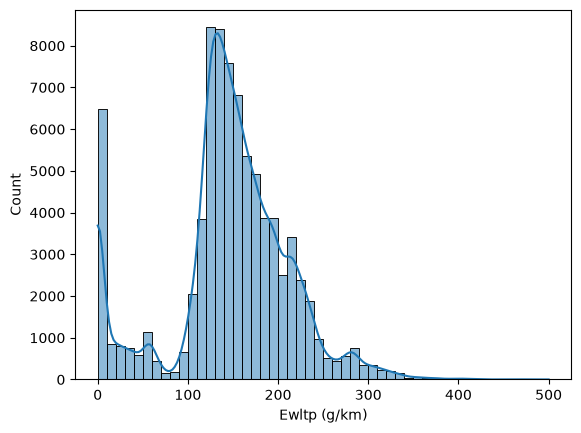

In [38]:
import seaborn as sns
sns.histplot(train_y, kde=True, bins=50)   # look for a long tail

-0.2920706101198645
-0.2920652759244502
mean: 146.35630448546243  median: 148.0


<Axes: >

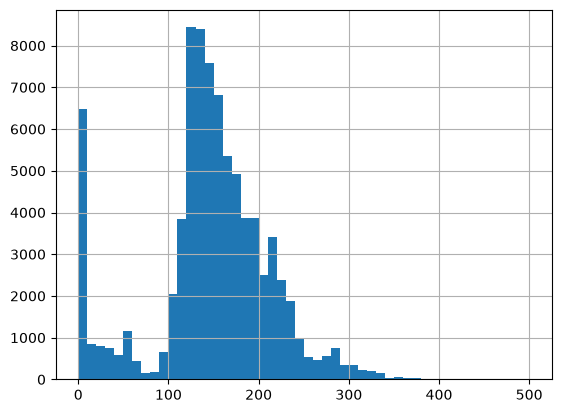

In [39]:
import scipy.stats as stats

print(train_y.skew())          # pandas
print(stats.skew(train_y))     # scipy — same idea
print("mean:", train_y.mean(), " median:", train_y.median())

train_y.hist(bins=50)          # eyeball it too

# 5. Cleaning
### Cleaning = removing or fixing rows/values that are wrong.
Dropping impossible cars, dropping missing-target rows, fixing typos, removing true duplicates. The defining feature: cleaning changes which rows exist. It's about the data's correctness.
Drop the rows your domain rules proved are errors. Drop missing-target rows. Note — you're only removing things you're confident are wrong here, not the ambiguous high-residual stuff, because you haven't computed residuals yet.

# 6. Mandatory preprocessing (no pipeline needed yet, or actually just a very simple pipeline like the one in the kaggle example)
### Mandatory preprocessing = transforming correct data into a format the model can eat.
### manual while you're learning what your data needs; pipeline once you're measuring performance.
### the transformations that have to happen for any model to run at all, plus cleaning. Impute missing features, encode categoricals, transform the target.
### impute missing features, encode categoricals, transform skewed target. Fit every parameter on train, apply to test
not trying to make the baseline's preprocessing optimal — you're trying to make it non-distorting, so the residuals you read are honest
keep doing your outlier and distribution EDA on train_y freely — it's correct and necessary. Just make sure that (a) you're doing none of it on the test set, and (b) any transform or removal you decide on gets fit on train and applied to test, not re-derived from test.

### a) Categorical variables (encoding)

A linear model takes ordinal encoding literally and gets misled by the fake ordering (Electric=0, Petrol=1, Diesel=2 implies a false magnitude relationship). So for your LinearRegression baseline you should one-hot your categoricals

In [40]:
# Get list of categorical variables
object_cols = list(train_X.select_dtypes(include=['object', 'category']).columns)

print("Categorical variables:")
print(object_cols)

# Apply one-hot encoder to each column with categorical data
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(train_X[object_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(val_X[object_cols]))

# One-hot encoding removed index; put it back
OH_cols_train.index = train_X.index
OH_cols_valid.index = val_X.index

# Remove categorical columns (will replace with one-hot encoding)
num_train_X = train_X.drop(object_cols, axis=1)
num_val_X = val_X.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_train_X = pd.concat([num_train_X, OH_cols_train], axis=1)
OH_val_X = pd.concat([num_val_X, OH_cols_valid], axis=1)

# Ensure all columns have string type
OH_train_X.columns = OH_train_X.columns.astype(str)
OH_val_X.columns = OH_val_X.columns.astype(str)

Categorical variables:
['Ft', 'Cr']


C:\Users\20017694\AppData\Local\Temp\ipykernel_10356\3539459809.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(train_X.select_dtypes(include=['object', 'category']).columns)


### b) Missing values
For a baseline, a plain median-impute on the numeric features is completely fine

In [41]:
# Imputation
my_imputer = SimpleImputer()
preprocessed_train_X = pd.DataFrame(my_imputer.fit_transform(OH_train_X))
preprocessed_val_X = pd.DataFrame(my_imputer.transform(OH_val_X))

# Imputation removed column names; put them back
preprocessed_train_X.columns = OH_train_X.columns
preprocessed_val_X.columns = OH_val_X.columns

### c) Target transform
apply it if the target's skewed, and remember to invert before reading residuals - otherwise your residuals are in log-units and you'll misjudge their size.

### e) Scaling / normalization
model-dependent. Linear models, SVMs, anything distance-based needs features on comparable scales (your mass in kg dwarfs engine_capacity in litres numerically). Tree models don't care — they split on thresholds, so scale is irrelevant to them. So for your XGBoost, skip it; for a linear baseline, it can matter

In [42]:
#Preprocessing & Feature Engineering
#imputing, pipelines, one hot encoding

# 7. Baseline residuals, appearance #1: as a diagnostic
Fit the quick baseline and look at the worst residuals. Why here and not earlier? Because a baseline model needs numeric, encoded, non-missing input to even run (recall: LinearRegression throws on NaNs and can't eat raw categoricals). So residuals structurally can't come before preprocessing — the model won't fit. This pass is the subtle outlier hunt: the ordinary-looking rows that passed every check in step 2 but the model still can't explain (the family-sedan-at-60-g/km case). You investigate these, and — carefully — decide row by row whether each is a real error (fix/drop) or just a limit of your simple model (leave it).

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(preprocessed_train_X, train_y)   # quick, rough
predictions = model.predict(preprocessed_train_X)
residuals = train_y - predictions                        # actual - predicted

residuals_view = train_X.copy()
residuals_view["CO2"] = train_y.copy()
residuals_view["residual"] = residuals

worst = residuals_view.reindex(residuals.abs().sort_values(ascending=False).index)
print(worst.head(20))

                     Ft   Cr  M (kg)  Ec (cm3)  Ep (KW)    CO2    residual
118341           petrol   M1  2035.0    2894.0    324.0  500.0  292.768284
118117  petrol/electric   M1  2310.0    1991.0    350.0  362.0  267.196854
15337            petrol   M1  1910.0    6498.0      NaN   57.0 -255.450606
117770  petrol/electric   M1  1922.0    1997.0    165.0  332.0  254.972185
117289  petrol/electric   M1  1893.0    1598.0    132.0  314.0  251.668953
118321           diesel   M1     NaN    2998.0    152.0  449.0  250.569240
118186  petrol/electric   M1  2500.0    2999.0    330.0  373.0  241.079373
118177  petrol/electric   M1  2500.0    2999.0    330.0  372.0  240.079373
118172  petrol/electric   M1  2485.0    2998.0    330.0  371.0  239.562173
118340           petrol   M1  1515.0    4800.0    588.0  500.0  238.738340
118178  petrol/electric   M1  2587.0    2999.0    300.0  372.0  238.485590
15145            petrol   M1  1700.0    6162.0      NaN   57.0 -238.441576
117852  petrol/electric  

I'll decide row by row whether each is a real error (fix/drop) or just a limit of my simple model (leave it).

Is the recorded value impossible, or is the prediction just too simple to reach it?

If the recorded number couldn't physically happen, the data is broken → fix/drop. If the recorded number is real and the straight line just can't bend to it, the model is too simple → leave it.

drop:
- ID 15337: 6.5L petrol can't be 57; Ep also NaN
- ID 15145: 6.2L petrol can't be 57; Ep NaN
- ID 15776: 5.0L petrol can't be 57; Ep NaN
- 10029: petrol impossible at 8
- 12537: 4.0L petrol impossible at 29
- 10755: diesel impossible at 14
- 14647: 4.0L / 456 kW petrol impossible at 51

Investigate:
- 118321: mass is NaN and 449 is high for a 152 kW diesel


In [44]:
# Probe: flag petrol/diesel rows with CO2 < 70 (physically impossible for combustion) — returned 977 rows all sharing NaN power, revealing a pattern rather than isolated typos.

# raw_train = the frame that generated your readable residual table
bad = train_X['Ft'].isin(['petrol', 'diesel']) & (train_y < 70)

train_X[bad]        # eyeball FIRST — expect exactly the 7 impossible rows

,Ft,Cr,M (kg),Ec (cm3),Ep (KW)
16562,petrol,M1,2213.0,1984.0,NaN
15865,petrol,M1,2617.0,1498.0,NaN
15307,petrol,M1,1892.0,1598.0,NaN
16745,petrol,M1,2234.0,1984.0,NaN
15687,petrol,M1,2449.0,2995.0,NaN
...,...,...,...,...,...
15099,petrol,M1,1660.0,1498.0,NaN
16558,petrol,M1,2209.0,1984.0,NaN
15545,petrol,M1,2167.0,1984.0,NaN
16247,petrol,M1,2148.0,1984.0,NaN


In [45]:
# Confirms 98% of the flagged rows are also missing Ep (power) — one population, two symptoms
# of the same reporting gap.
train_X[bad]['Ep (KW)'].isna().mean()      # is it ALL of them?  expect ~1.0

np.float64(0.9795291709314228)

In [46]:
# Confirms the target is a placeholder, not real data: the value 57 is repeated 742 times,
# which no real emissions process would produce.
train_y[bad].value_counts().head()         # is CO2 basically one repeated value?

Ewltp (g/km)
57.0    742
59.0     55
58.0     30
60.0     26
67.0     21
Name: count, dtype: int64

In [47]:
# NEW — drop the Ep condition. Nothing real in pure petrol/diesel sits below 70,
# so fuel + impossibility is the COMPLETE filter. The Ep-NaN clause was superb
# EVIDENCE (it proved the 57s were a systematic gap) but as a filter it wrongly
# spares the ~20 single-digit fakes that DO have a real Ep (diesel@5 Ep 145,
# petrol@7 Ep 140 — visible in your probe). This mask is just `bad` from cell 66.

placeholder = train_X['Ft'].isin(['petrol', 'diesel']) & (train_y < 70)
placeholder.sum()      # ~977 now (was 957); the extra ~20 are the Ep-present fakes

np.int64(977)

In [48]:
# NEW
keep = ~placeholder
# RAW clean frames — Ft/Cr intact so the tree PIPELINE (cell 79) encodes them itself.
# Mask is built on train_X and shares its index, so plain boolean indexing aligns —
# no .to_numpy(), no "Unalignable" error.
train_X_clean = train_X[keep]
train_y_clean = train_y[keep]

# Preprocessed clean — ONLY for the throwaway baseline re-check below (LinearRegression
# needs the encoded matrix; preprocessed_* has a reset index, hence .to_numpy()).
prep_train_clean = preprocessed_train_X[keep.to_numpy()]

In [49]:
len(train_X_clean), len(train_y_clean), (~placeholder).sum()   # first two equal, and match the third (~957 fewer than original)

(81155, 81155, np.int64(81155))

In [50]:
# --- validation-set label cleaning (independent of train) ---
# Same placeholder logic as train, but derived from TEST columns only — no train-derived
# values used here. These rows have a fabricated CO2 (~57) so there's no ground truth to
# score against; removing them keeps evaluation honest. This is label integrity, NOT
# model-dependent preprocessing, so it correctly applies to test as well as train.

val_placeholder = val_X['Ft'].isin(['petrol','diesel']) & (val_y < 70)

val_keep = ~val_placeholder
val_X_clean = val_X[val_keep]          # RAW — feeds the pipeline
val_y_clean = val_y[val_keep]
prep_val_clean = preprocessed_val_X[val_keep.to_numpy()]   # for the baseline re-check

val_placeholder.sum(), len(val_X_clean)

(np.int64(451), 34749)

In [51]:
len(val_X_clean), len(val_y_clean), val_keep.sum()   # all consistent

(34749, 34749, np.int64(34749))

Now we'll see if the cleaning made the corrupt tail disappear.

In [52]:
model.fit(prep_train_clean, train_y_clean)
resid = train_y_clean - model.predict(prep_train_clean)
resid.min(), resid.max()

(np.float64(-214.71629602452828), np.float64(289.59144604634275))

Now the real baseline. The honest performance on clean val, and what we'll compare our tree models against.

In [53]:
preds_val = model.predict(prep_val_clean)
mean_absolute_error(val_y_clean, preds_val), r2_score(val_y_clean, preds_val), root_mean_squared_error(val_y_clean, preds_val)

(22.937737342666434, 0.7556920597422114, 33.421008915809324)

# 9. Model selection + tuning
### Pipeline needed: pipeline isn't a convenience, it's a correctness requirement: it's the thing that re-fits your preprocessing inside each CV fold so no information leaks across folds
Your encoding-and-hyperparameter comparison lives here. Now you try tree/forest/xgboost, and this is where one-hot-vs-ordinal gets tested, because — key point — the right encoding is model-dependent, so it can only be decided while choosing the model, not before.

##### train your actual tuned model (XGBoost, whatever), cross-validate, tune.
I'm using RMSE, MAE, and R^2. MAE will be my headline metric for interpretability, but I'll also report RMSE and R² alongside it. RMSE will let me know if I am ever badly wrong, and R² says will let me know if I am beating just guessing the average.

In [54]:
# ============================================================
# Regression with three tree models: Decision Tree, Random Forest, XGBoost
#
#   - reports RMSE, MAE, and R^2
#   - CV is a single toggle so you can compare k-fold vs single holdout
# ============================================================

# STEP 1 - CV strategy as a single toggle.
# USE_CV = True  -> 5-fold cross-validation (robust, ~5x slower)
# USE_CV = False -> ONE held-out validation split (fast; often plenty at 188k rows)
# Run both ways and compare: do the chosen hyperparameters differ? how much slower is k-fold? With lots of rows the answer is usually "barely" and "a lot".
# ------------------------------------------------------------
USE_CV = True
CV = 5 if USE_CV else ShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)


# ------------------------------------------------------------
# STEP 2 - Preprocessor builder.
# "cat" branch encodes categoricals; "num" branch imputes missing numerics.
# BOTH the encoder and the imputer are LEARNED-FROM-VALUES transforms, so they
# live inside the pipeline and get refit per fold on training data only.
# remainder="passthrough" keeps any leftover columns (e.g. bool) untouched.
# ------------------------------------------------------------
def make_prep(cat_encoder, num_transformer):
    return ColumnTransformer(
        transformers=[
            ("cat", cat_encoder, cat_cols),
            ("num", num_transformer, num_cols),
        ],
        remainder="passthrough",
    )

# Reusable transform options (GridSearchCV clones these, so sharing is fine):
ordinal   = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
onehot    = OneHotEncoder(handle_unknown="ignore")
imp_mean   = SimpleImputer(strategy="mean")
imp_median = SimpleImputer(strategy="median")

# ------------------------------------------------------------
# STEP 3 - Define all three pipelines (cheap: no computation yet).
# The transforms passed here are just DEFAULTS. GridSearchCV overrides them via
# the grids below, so what you write here barely matters - every model ends up
# testing every encoder / imputer option listed in its grid.
# ------------------------------------------------------------
pipelines = {
    "decision_tree": Pipeline([
        ("prep",  make_prep(ordinal, imp_median)),
        ("model", DecisionTreeRegressor(random_state=SEED)),
    ]),
    "random_forest": Pipeline([
        ("prep",  make_prep(ordinal, imp_median)),
        ("model", RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    ]),
    "xgboost": Pipeline([
        ("prep",  make_prep(onehot, imp_median)),
        ("model", XGBRegressor(random_state=SEED, n_jobs=-1)),
    ]),
}


# ------------------------------------------------------------
# STEP 4 - Per-model grids = the search space GridSearchCV explores.
#   prep__cat  -> rotates the ENCODER (ordinal vs one-hot) for every model
#   prep__num  -> rotates the IMPUTER (mean vs median); XGBoost also gets
#                 "passthrough" so you can test native NaN handling vs imputing
#   model__... -> the usual model knobs
# ------------------------------------------------------------
param_grids = {
    "decision_tree": {
        "prep__cat": [ordinal, onehot],
        "prep__num": [imp_mean, imp_median],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 20],
    },
    "random_forest": {
        "prep__cat": [ordinal, onehot],
        "prep__num": [imp_mean, imp_median],
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__max_features": ["sqrt", 1.0],
    },
    "xgboost": {
        "prep__cat": [ordinal, onehot],
        "prep__num": [imp_mean, imp_median, "passthrough"],   # passthrough = keep NaN, let XGBoost handle it
        "model__n_estimators": [200, 400],
        "model__max_depth": [3, 6, 10],
        "model__learning_rate": [0.05, 0.1],
    },
}


# ------------------------------------------------------------
# STEP 5 - Tune each model, scoring THREE metrics at once.
# refit="rmse" means the WINNER is chosen by RMSE, but MAE and R^2 are recorded
# too so you can compare. (neg_* because sklearn maximizes; we flip signs back.)
# So we get the best pipeline by RMSE and we test it with RMSE/MAE/R2. It's one best combo by RMSE shown three ways.
# ------------------------------------------------------------
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":  "neg_mean_absolute_error",
    "r2":   "r2",
}

#using RandomizedSearchCV first then switching to GridSearchCV
#How GridSearchCV works. The mechanism is simple once you see it. You hand it an
#estimator (your pipeline) and a param_grid (a dict of lists). It builds the Cartesian product
#— every possible combination of those lists — and for each combination it runs cross-
#validation: fit on the training folds, score on the held-out fold, repeat for all folds, average. So
#the total number of model fits is (number of combinations) × (number of folds). It
#records every combo's average score, picks the best, and — this is the part people miss —
#refits that winning combo on the entire training set (no folds held out) to produce the final
#main arguments:
    #estimator — the pipeline to tune.
    #param_grid — the search space (stepname__param: [values]).
    #cv — an integer for k-fold, or a splitter object (this is your USE_CV toggle).
    #scoring — one metric, or several (string, list, or dict).
    #refit — when you score multiple metrics, this names the one metric used to pick the winner and to trigger the final refit.
    #n_jobs=-1 — use all CPU cores in parallel.
#After .fit(), it exposes best_params_, best_score_, best_index_, best_estimator_ (the refit pipeline), and cv_results_ (the full table of every combo's scores).

results = {}
for name, pipe in pipelines.items():       #for each pipeline in the dictionary pipelines
    search = RandomizedSearchCV(                 # use GridSearchCV (at the end search contains a pipeline with the best hyperparameter)
        pipe, param_grids[name],            # to go through this specific pipeline (pipe) using these specific hyperparameters (param_grids[name])
        cv=CV, scoring=scoring, refit="rmse", verbose=2, n_jobs=-1,      # with (CV) folds, scoring with the scoring methods in the dictionary (scoring),
    )                                                         # using (refit) as the scoring method we'll actually declare a winner with
    search.fit(train_X_clean, train_y_clean)                 # all tuning on TRAIN only. search contains a pipeline that we're fitting onto our training data.

    # CV scores for the winning combo (pulled at the best index):
    i = search.best_index_                      #Get index position of the winning hyperparameter combination
    cvr = search.cv_results_                    #creates a dictionairy "cvr" with all the CV results
    cv_rmse = -cvr["mean_test_rmse"][i]         #fetches the best score from the relevant scoring method (Look up the RMSE array, then grab the score at index `i`)
    cv_mae  = -cvr["mean_test_mae"][i]          #fetches the best score from the relevant scoring method (Look up the MAE array, then grab the score at index `i`)
    cv_r2   =  cvr["mean_test_r2"][i]           #fetches the best score from the relevant scoring method (Look up the R2 array, then grab the score at index `i`)

    # Honest one-shot evaluation on the locked test set using the best results:
    preds = search.predict(val_X_clean)                         #remember, search is a pipeline with the best hyperparameters. so now we take our validation data and put it into our best pipeline to create predictions
    test_rmse = root_mean_squared_error(val_y_clean, preds)       # and now we check how accurate those predictions are
    test_mae  = mean_absolute_error(val_y_clean, preds)
    test_r2   = r2_score(val_y_clean, preds)

    results[name] = {"cv_rmse": cv_rmse, "test_rmse": test_rmse,
                     "test_mae": test_mae, "test_r2": test_r2,
                     "best_params": search.best_params_}

    print(f"{name:14s} | CV RMSE={cv_rmse:8.3f} || "
          f"Test RMSE={test_rmse:8.3f}  MAE={test_mae:8.3f}  R2={test_r2:.4f}")
    print(f"               best params: {search.best_params_}\n")


# ------------------------------------------------------------
# STEP 6 - The "evolution" view: models printed in increasing complexity.
# Winner is chosen by CV RMSE (never by test RMSE - that would spoil the honest
# estimate). Expect DT < RF <= XGB usually, but verify rather than assume.
# ------------------------------------------------------------
print("Progression (by test RMSE):")
for name in ["decision_tree", "random_forest", "xgboost"]:
    r = results[name]
    print(f"  {name:14s} test RMSE={r['test_rmse']:8.3f}  R2={r['test_r2']:.4f}")

best_model = min(results, key=lambda k: results[k]["cv_rmse"])
print(f"\nWinner (by CV): {best_model} | honest test RMSE "
      f"{results[best_model]['test_rmse']:.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
decision_tree  | CV RMSE=  20.065 || Test RMSE=  19.989  MAE=   9.972  R2=0.9126
               best params: {'prep__num': SimpleImputer(strategy='median'), 'prep__cat': OneHotEncoder(handle_unknown='ignore'), 'model__min_samples_leaf': 5, 'model__max_depth': 20}

Fitting 5 folds for each of 10 candidates, totalling 50 fits
random_forest  | CV RMSE=  18.898 || Test RMSE=  18.996  MAE=   9.365  R2=0.9211
               best params: {'prep__num': SimpleImputer(strategy='median'), 'prep__cat': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), 'model__n_estimators': 400, 'model__max_features': 1.0, 'model__max_depth': 20}

Fitting 5 folds for each of 10 candidates, totalling 50 fits
xgboost        | CV RMSE=  18.696 || Test RMSE=  18.732  MAE=  10.055  R2=0.9233
               best params: {'prep__num': 'passthrough', 'prep__cat': OneHotEncoder(handle_unknown='ignore'), 'model__n_estimators': 200, 'model__max_

# 11. Baseline residuals, appearance #2: as evaluation
After your real model is trained, you look at its residuals again — but now the job is different. Here it's not outlier-hunting; it's diagnosing the model. Residual plots that still show a pattern (a curve, a fan shape widening at high emissions) tell you the model is missing structure — maybe you need a non-linear model, or a feature is missing, or the target needed a transform. Same tool, totally different purpose: step 5 asks "which rows are bad?", step 7 asks "what is my model getting wrong?"

In [56]:
import pandas as pd
import numpy as np

# Build a diagnostic frame: actuals, predictions, and the error
diag = val_X_clean.copy()
diag['actual'] = val_y_clean.values
diag['predicted'] = preds
diag['error'] = diag['actual'] - diag['predicted']      # signed: + means model UNDER-predicted
diag['abs_error'] = diag['error'].abs()
diag['pct_error'] = (diag['abs_error'] / diag['actual']) * 100

# The 20 worst misses
worst = diag.sort_values('abs_error', ascending=False).head(20)
print(worst)

                     Ft  Cr  M (kg)  Ec (cm3)  Ep (KW)  actual   predicted  \
114310  petrol/electric  M1  2325.0    1999.0    185.0   270.0   53.367981   
116540  petrol/electric  M1  2810.0    2996.0    294.0   298.0   87.002213   
116415  petrol/electric  M1  2810.0    2996.0    294.0   295.0   87.002213   
118088           petrol  M1  1845.0    1498.0    118.0   358.0  159.098038   
113882  petrol/electric  M1  2780.0    2998.0    330.0   263.0   64.553566   
118329           diesel  M1  3273.0    2184.0    132.0   463.0  268.270264   
114738  petrol/electric  M1  2493.0    1995.0    200.0   276.0   83.371506   
118046           petrol  M1  1877.0    1998.0    131.0   353.0  161.981232   
14689   petrol/electric  M1  2580.0    3996.0    456.0    51.0  241.069107   
118179  petrol/electric  M1  2587.0    2999.0    330.0   372.0  187.314468   
107258  diesel/electric  M1  2185.0    1993.0    145.0   225.0   40.808968   
110241  petrol/electric  M1  2145.0    2360.0    100.0   234.0  

In [58]:
worst_50 = diag.sort_values('abs_error', ascending=False).head(50)

# Is one fuel type massively over-represented in the misses?
print("Fuel mix — worst misses:")
print(worst_50['Ft'].value_counts(normalize=True))
print("\nFuel mix — whole test set:")
print(diag['Ft'].value_counts(normalize=True))

Fuel mix — worst misses:
Ft
petrol/electric    0.86
petrol             0.08
diesel/electric    0.04
diesel             0.02
Name: proportion, dtype: float64

Fuel mix — whole test set:
Ft
petrol             0.490949
diesel             0.324527
petrol/electric    0.086592
electric           0.077009
lpg                0.010446
diesel/electric    0.009382
e85                0.000719
ng                 0.000173
hydrogen           0.000115
unknown            0.000086
Name: proportion, dtype: float64


# 11. Financed-emissions estimator: three-regime router

The trained XGBoost model above answers the ICE case well, but a bank's loan book contains every powertrain type, and the three types are three *different* problems:

- **ICE (petrol/diesel)** — emissions are essentially a function of the vehicle hardware, so the ML model handles these.
- **BEV (pure electric)** — tailpipe CO2 is zero by definition, so this is an *assignment*, not a prediction.
- **PHEV (petrol/electric, diesel/electric)** — certified emissions depend on an assumed electric-driving share (the WLTP utility factor) that vehicle features cannot observe. Real-world emissions run materially higher than the certificate (ICCT 2022-2024: real-world fuel consumption ~42-67% above label). So the defensible move is to take the certified value and apply a documented real-world **correction factor**, scaled by electric range where available.

This section wraps the existing model in a router that sends each car to the right method. Nothing above is modified.

**Known limitation (follow-up):** the XGBoost pipeline above was trained on all fuel types, not ICE-only. The router still routes ICE cars to it, but a cleaner version would retrain the ICE branch on petrol/diesel rows alone. That retraining is deliberately left as the next step so the existing pipeline stays untouched.

### a) Pull certified emissions + electric range for the PHEV branch
`car_data` above doesn't carry `Zr` (electric range), which the PHEV correction needs. Pull it here per distinct spec. `Zr` is only populated for electrified vehicles, so blanks on ICE rows are expected and harmless.

In [60]:
# Zr = electric range (only meaningful for electrified vehicles).
Zr = "[Zr]"
phev_ref = disco(
    f"SELECT DISTINCT {Ewltp}, Ft, Cr, {M}, {Ec}, {Ep}, {Zr} FROM {TBL}",
    n=160000
)
print(phev_ref.shape)

# Median certified value among true PHEVs, used only as a last-resort fallback
# when a PHEV row is missing its own Ewltp.
is_phev_ref = phev_ref['Ft'].str.contains('/electric', case=False, na=False)
phev_median_ewltp = phev_ref.loc[is_phev_ref, 'Ewltp (g/km)'].median()
print('PHEV rows:', int(is_phev_ref.sum()), ' | median certified Ewltp:', phev_median_ewltp)

(153739, 7)
PHEV rows: 16988  | median certified Ewltp: 43.0


### b) PHEV correction factor
The certified figure understates real-world emissions because the test assumes more electric driving than happens in practice. Longer electric range -> the certificate is closer to reality -> smaller correction. The multipliers below reflect the *direction and rough magnitude* published by ICCT/SAE; they are documented approximations, **not** fitted to this registry (registry data contains only the certified value, so the real-world gap cannot be derived from it). The tiered fallback degrades gracefully when `Zr` or `Ewltp` is missing.

In [61]:
import numpy as np

FLAT_CORRECTION = 1.45   # ICCT central estimate of real-world / label gap

def correction_factor(zr):
    """Real-world correction multiplier as a function of electric range (km).
    Longer range -> smaller correction. Unknown range -> flat fallback."""
    if zr is None or (isinstance(zr, float) and np.isnan(zr)):
        return FLAT_CORRECTION
    if zr >= 60:
        return 1.25
    if zr >= 40:
        return 1.40
    if zr >= 20:
        return 1.55
    return 1.70

def estimate_phev_emissions(ewltp, zr, phev_median):
    """Tiered PHEV estimate:
       best  -> certified value x range-conditional correction
       ok    -> certified value x flat correction (range missing)
       last  -> group-median certified value x flat correction (certificate missing)"""
    has_ewltp = ewltp is not None and not (isinstance(ewltp, float) and np.isnan(ewltp))
    has_zr    = zr    is not None and not (isinstance(zr, float)    and np.isnan(zr))
    if has_ewltp and has_zr:
        return correction_factor(zr) * ewltp
    elif has_ewltp:
        return FLAT_CORRECTION * ewltp
    else:
        return FLAT_CORRECTION * phev_median

### c) Top-level router
Routes each car by fuel type: pure `electric` -> 0; any `/electric` hybrid -> corrected certified value; everything else (petrol/diesel/lpg/etc.) -> the trained XGBoost pipeline. The `best_model`/`results` objects come from the tuning loop above; the winning fitted pipeline is `search.best_estimator_` for the winning model — re-fetched here without changing the loop.

In [62]:
# The tuning loop kept only the LAST `search` in scope. To route ICE cars we need
# the winning pipeline specifically. Re-fit the winner's pipeline on the clean
# training data so the router has a dedicated ICE estimator (does not touch the loop).
from sklearn.base import clone

ice_pipeline = clone(pipelines[best_model])
ice_pipeline.set_params(**results[best_model]['best_params'])
ice_pipeline.fit(train_X_clean, train_y_clean)
ICE_FEATURES = features   # ['Ft','Cr','M (kg)','Ec (cm3)','Ep (KW)']
print('ICE branch uses:', best_model, '->', results[best_model]['best_params'])

ICE branch uses: xgboost -> {'prep__num': 'passthrough', 'prep__cat': OneHotEncoder(handle_unknown='ignore'), 'model__n_estimators': 200, 'model__max_depth': 10, 'model__learning_rate': 0.05}


In [63]:
def estimate_co2(row, ice_model, phev_median):
    """Return an estimated WLTP CO2 (g/km) for a single vehicle row."""
    ft = str(row['Ft']).lower()

    # BEV: pure electric -> zero tailpipe
    if ft == 'electric':
        return 0.0

    # PHEV: dual-fuel hybrid -> certified value + real-world correction
    if '/electric' in ft:
        return estimate_phev_emissions(row.get('Ewltp (g/km)'), row.get('Zr'), phev_median)

    # ICE (and other combustion fuels): the ML model
    X_one = row[ICE_FEATURES].to_frame().T
    return float(ice_model.predict(X_one)[0])

### d) Apply across the fleet and sanity-check the PHEV correction
There is no real-world ground truth to score PHEVs against (same reason the correction can't be fitted), so validation is a *plausibility* check: corrected PHEV values should sit meaningfully above their certificates, and an engine-heavy PHEV should land in a realistic combustion-like range rather than the implausibly low certified figure.

In [64]:
# Apply the router to the per-spec reference frame.
phev_ref = phev_ref.copy()
phev_ref['co2_estimate'] = phev_ref.apply(
    lambda r: estimate_co2(r, ice_pipeline, phev_median_ewltp), axis=1
)

# --- sanity check on PHEVs only ---
phev_rows = phev_ref[phev_ref['Ft'].str.contains('/electric', case=False, na=False)].copy()
phev_rows['lift'] = phev_rows['co2_estimate'] / phev_rows['Ewltp (g/km)']

print('PHEV corrected vs certified (should be >= certified):')
print(phev_rows[['Ewltp (g/km)', 'Zr', 'co2_estimate', 'lift']].describe())

# Spot-check the extreme case: big engine, absurdly low certificate
big = phev_rows.sort_values('Ec (cm3)', ascending=False).head(5)
print('\nLargest-engine PHEVs (certified -> corrected):')
print(big[['Ft', 'M (kg)', 'Ec (cm3)', 'Ep (KW)', 'Zr', 'Ewltp (g/km)', 'co2_estimate']])

PHEV corrected vs certified (should be >= certified):
       Ewltp (g/km)            Zr  co2_estimate          lift
count  16868.000000  11856.000000  16988.000000  16868.000000
mean      73.434551     94.858553    100.712147      1.331240
std       67.774012     47.181942     96.586368      0.096522
min        2.000000     11.000000      2.500000      1.250000
25%       21.000000     66.000000     27.500000      1.250000
50%       43.000000     83.000000     58.750000      1.250000
75%      119.000000    112.000000    165.000000      1.450000
max      406.000000    664.000000    686.800000      1.700000

Largest-engine PHEVs (certified -> corrected):
                     Ft  M (kg)  Ec (cm3)  Ep (KW)    Zr  Ewltp (g/km)  \
153394  petrol/electric  1985.0    6498.0    607.0  13.0         350.0   
153687  petrol/electric  1985.0    6498.0    607.0   NaN         406.0   
153682  petrol/electric  1967.0    6498.0    607.0  13.0         404.0   
100755  petrol/electric  1967.0    6498.0   

# 13. Retrain the ICE branch on combustion-only vehicles

The model in Sections 9-12 was trained on every fuel type, including the plug-in hybrids whose certified emissions are set by an unobservable utility-factor assumption. Those PHEV rows both inflate error and corrupt what the model learns about the genuine hardware->emissions relationship. Here we retrain the same three-model bake-off on **combustion-only** vehicles and compare honestly against the all-fuel numbers above.

**Scope decision.** "ICE" here = petrol, diesel, lpg, e85, ng - fuels where CO2 tracks the hardware. Excluded: the `/electric` hybrids (unobservable usage), pure `electric` (zero, router-handled), `hydrogen` (fuel-cell, ~0 CO2, behaves like BEV not ICE), and `unknown` (unclassifiable, 4 rows). The router is updated to send hydrogen to 0 alongside BEVs.

This is additive: the Section 9 loop and its results are left intact, so you can read the before/after side by side.

### a) Build combustion-only clean train / validation sets
Reuses the existing `train_X_clean` / `val_X_clean` frames (placeholder-57 rows already removed), then filters to combustion fuels. No new split - the same rows that were in train stay in train, so the comparison is apples-to-apples.

In [65]:
ICE_FUELS = ['petrol', 'diesel', 'lpg', 'e85', 'ng']

ice_tr_mask = train_X_clean['Ft'].isin(ICE_FUELS)
ice_va_mask = val_X_clean['Ft'].isin(ICE_FUELS)

ice_train_X = train_X_clean[ice_tr_mask]
ice_train_y = train_y_clean[ice_tr_mask]
ice_val_X   = val_X_clean[ice_va_mask]
ice_val_y   = val_y_clean[ice_va_mask]

print('ICE train rows:', len(ice_train_X), 'of', len(train_X_clean),
      '| ICE val rows:', len(ice_val_X), 'of', len(val_X_clean))
print('\nFuel mix now in training set:')
print(ice_train_X['Ft'].value_counts())

ICE train rows: 67229 of 81155 | ICE val rows: 28731 of 34749

Fuel mix now in training set:
Ft
petrol    39726
diesel    26588
lpg         848
e85          60
ng            7
Name: count, dtype: int64


### b) Retrain the same three models on ICE-only data
Identical pipelines, grids, CV, and scoring as Section 9 - only the training data changed. Winner still chosen by CV RMSE; test numbers reported on the ICE-only clean validation set. Compare these directly against the all-fuel run above.

In [66]:
ice_results = {}
for name, pipe in pipelines.items():
    search = RandomizedSearchCV(
        clone(pipe), param_grids[name],
        cv=CV, scoring=scoring, refit='rmse', verbose=1, n_jobs=-1,
    )
    search.fit(ice_train_X, ice_train_y)

    i   = search.best_index_
    cvr = search.cv_results_
    cv_rmse = -cvr['mean_test_rmse'][i]
    cv_mae  = -cvr['mean_test_mae'][i]
    cv_r2   =  cvr['mean_test_r2'][i]

    preds     = search.predict(ice_val_X)
    test_rmse = root_mean_squared_error(ice_val_y, preds)
    test_mae  = mean_absolute_error(ice_val_y, preds)
    test_r2   = r2_score(ice_val_y, preds)

    ice_results[name] = {'cv_rmse': cv_rmse, 'test_rmse': test_rmse,
                         'test_mae': test_mae, 'test_r2': test_r2,
                         'best_params': search.best_params_,
                         'estimator': search.best_estimator_}

    print(f"{name:14s} | CV RMSE={cv_rmse:8.3f} || "
          f"Test RMSE={test_rmse:8.3f}  MAE={test_mae:8.3f}  R2={test_r2:.4f}")

ice_best_model = min(ice_results, key=lambda k: ice_results[k]['cv_rmse'])
print(f"\nWinner (by CV): {ice_best_model} | honest test RMSE "
      f"{ice_results[ice_best_model]['test_rmse']:.3f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
decision_tree  | CV RMSE=  15.331 || Test RMSE=  15.016  MAE=   8.691  R2=0.8957
Fitting 5 folds for each of 10 candidates, totalling 50 fits
random_forest  | CV RMSE=  14.411 || Test RMSE=  14.192  MAE=   8.130  R2=0.9068
Fitting 5 folds for each of 10 candidates, totalling 50 fits
xgboost        | CV RMSE=  14.258 || Test RMSE=  13.995  MAE=   8.308  R2=0.9094

Winner (by CV): xgboost | honest test RMSE 13.995


### c) Before / after comparison
All-fuel model (Section 9) vs ICE-only model, both on their respective honest test sets. MAE is the headline; watch whether the RMSE/MAE gap shrinks (fewer wild misses now that the PHEVs are gone) and whether MAE-as-a-percent-of-mean drops toward the 5% target.

In [67]:
ice_mean = ice_val_y.mean()
print(f"{'model':<16}{'RMSE':>9}{'MAE':>9}{'R2':>9}{'MAE % of mean':>16}")
print('-' * 59)

# all-fuel winner from Section 9
af = results[best_model]
af_mean = val_y_clean.mean()
print(f"{'all-fuel ('+best_model+')':<16}{af['test_rmse']:>9.3f}"
      f"{af['test_mae']:>9.3f}{af['test_r2']:>9.4f}"
      f"{100*af['test_mae']/af_mean:>15.1f}%")

# ICE-only winner
ic = ice_results[ice_best_model]
print(f"{'ICE-only ('+ice_best_model+')':<16}{ic['test_rmse']:>9.3f}"
      f"{ic['test_mae']:>9.3f}{ic['test_r2']:>9.4f}"
      f"{100*ic['test_mae']/ice_mean:>15.1f}%")

print(f"\nNote: the two rows are scored on different test sets "
      f"(all-fuel n={len(val_y_clean)}, ICE-only n={len(ice_val_y)}), so this "
      f"compares each model on the population it's meant to serve, not row-for-row.")

model                RMSE      MAE       R2   MAE % of mean
-----------------------------------------------------------
all-fuel (xgboost)   18.732   10.055   0.9233            6.8%
ICE-only (xgboost)   13.995    8.308   0.9094            5.0%

Note: the two rows are scored on different test sets (all-fuel n=34749, ICE-only n=28731), so this compares each model on the population it's meant to serve, not row-for-row.


### d) Point the router at the ICE-only model + send hydrogen to 0
Redefine `ice_pipeline` to the combustion-only winner and update the router so hydrogen (fuel-cell, ~0 CO2) is assigned 0 like BEVs rather than pushed through the ICE model. Overwrites the Section 12 definitions in place; rerun the Section 12d apply cell afterward to regenerate `co2_estimate` with the cleaner branch.

In [68]:
# Swap the router's ICE branch to the combustion-only model.
ice_pipeline = ice_results[ice_best_model]['estimator']
print('Router ICE branch now:', ice_best_model)

ZERO_CO2_FUELS = ('electric', 'hydrogen')   # BEV + fuel-cell -> zero tailpipe

def estimate_co2(row, ice_model, phev_median):
    """Return an estimated WLTP CO2 (g/km) for a single vehicle row."""
    ft = str(row['Ft']).lower()

    # BEV / fuel-cell -> zero tailpipe
    if ft in ZERO_CO2_FUELS:
        return 0.0

    # PHEV: dual-fuel hybrid -> certified value + real-world correction
    if '/electric' in ft:
        return estimate_phev_emissions(row.get('Ewltp (g/km)'), row.get('Zr'), phev_median)

    # ICE (petrol/diesel/lpg/e85/ng) -> the combustion-only ML model
    X_one = row[ICE_FEATURES].to_frame().T
    return float(ice_model.predict(X_one)[0])

Router ICE branch now: xgboost
